# Demand Estimation and Market Analysis: Air Fryers

In this lab, you will study the market for air fryers using brand-year data aggregated from Amazon purchases. The goal is to move from descriptive analysis to a simple demand model, and then use that model to infer markups and unit costs.

Use the cleaned file:

```python
air_fryers_clean_brand_year.csv
```

This file keeps the top 10 air-fryer brands from 2019-2023 and drops the long tail of very small brands. The variable `brand_share` has already been recomputed within this cleaned name-brand market, so shares sum to 1 within each year.

## Data

Each row is one brand in one year.

Important columns:

- `year`: calendar year
- `brand`: air-fryer brand
- `purchase_count`: number of purchases by that brand in that year
- `product_count`: number of distinct products observed for that brand-year
- `avg_price`: average price for that brand-year
- `avg_rating`: average review rating for that brand-year
- `brand_share`: purchase share within the cleaned air-fryer market in that year
- `log_brand_share`: `np.log(brand_share)`, already computed for convenience
- `compact_share`, `dual_basket_share`, `oven_style_share`, `rotisserie_share`, `window_share`: product characteristic shares for the brand-year

The original lecture wrote the demand equation using an outside option:

$$
\log(s_{bt}) - \log(s_{ot}).
$$

For this cleaned dataset, we dropped the nuisance long-tail brands instead of treating them as an outside option. You should therefore use:

$$
y_{bt} = \log(s_{bt})
$$

as the outcome and include **year dummies**. The year dummies absorb the year-specific denominator of the multinomial logit share equation. This keeps the assignment focused on the cleaned name-brand market.

## 1. Data Analysis

Load `air_fryers_clean_brand_year.csv`.

1. Verify that the data contain 10 brands and the years 2019-2023.
2. Plot the following over time by brand:
   - average price
   - average rating
   - brand market share
3. Summarize the product characteristics:
   - Which features are common?
   - Which features are rare?
   - Are there brands that seem to specialize in different product types?
4. Write a short paragraph describing the market. Which brands are expensive? Which brands have large shares? Does the market look stable over time?

This part of the work is the **data analyst** role: making the data trustworthy, visual, and interpretable before building a model.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("/content/air_fryers_clean_brand_year.csv")

feature_cols = [
    "compact_share",
    "dual_basket_share",
    "oven_style_share",
    "rotisserie_share",
    "window_share",
]

df.head()


,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364


Number of brands: 10
Brands: ['chefman', 'cosori', 'cuisinart', 'dash', 'gowise usa', 'instant_pot', 'ninja', 'nuwave', 'oster', 'ultrean']
Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Contains 10 brands and years 2019-2023: True


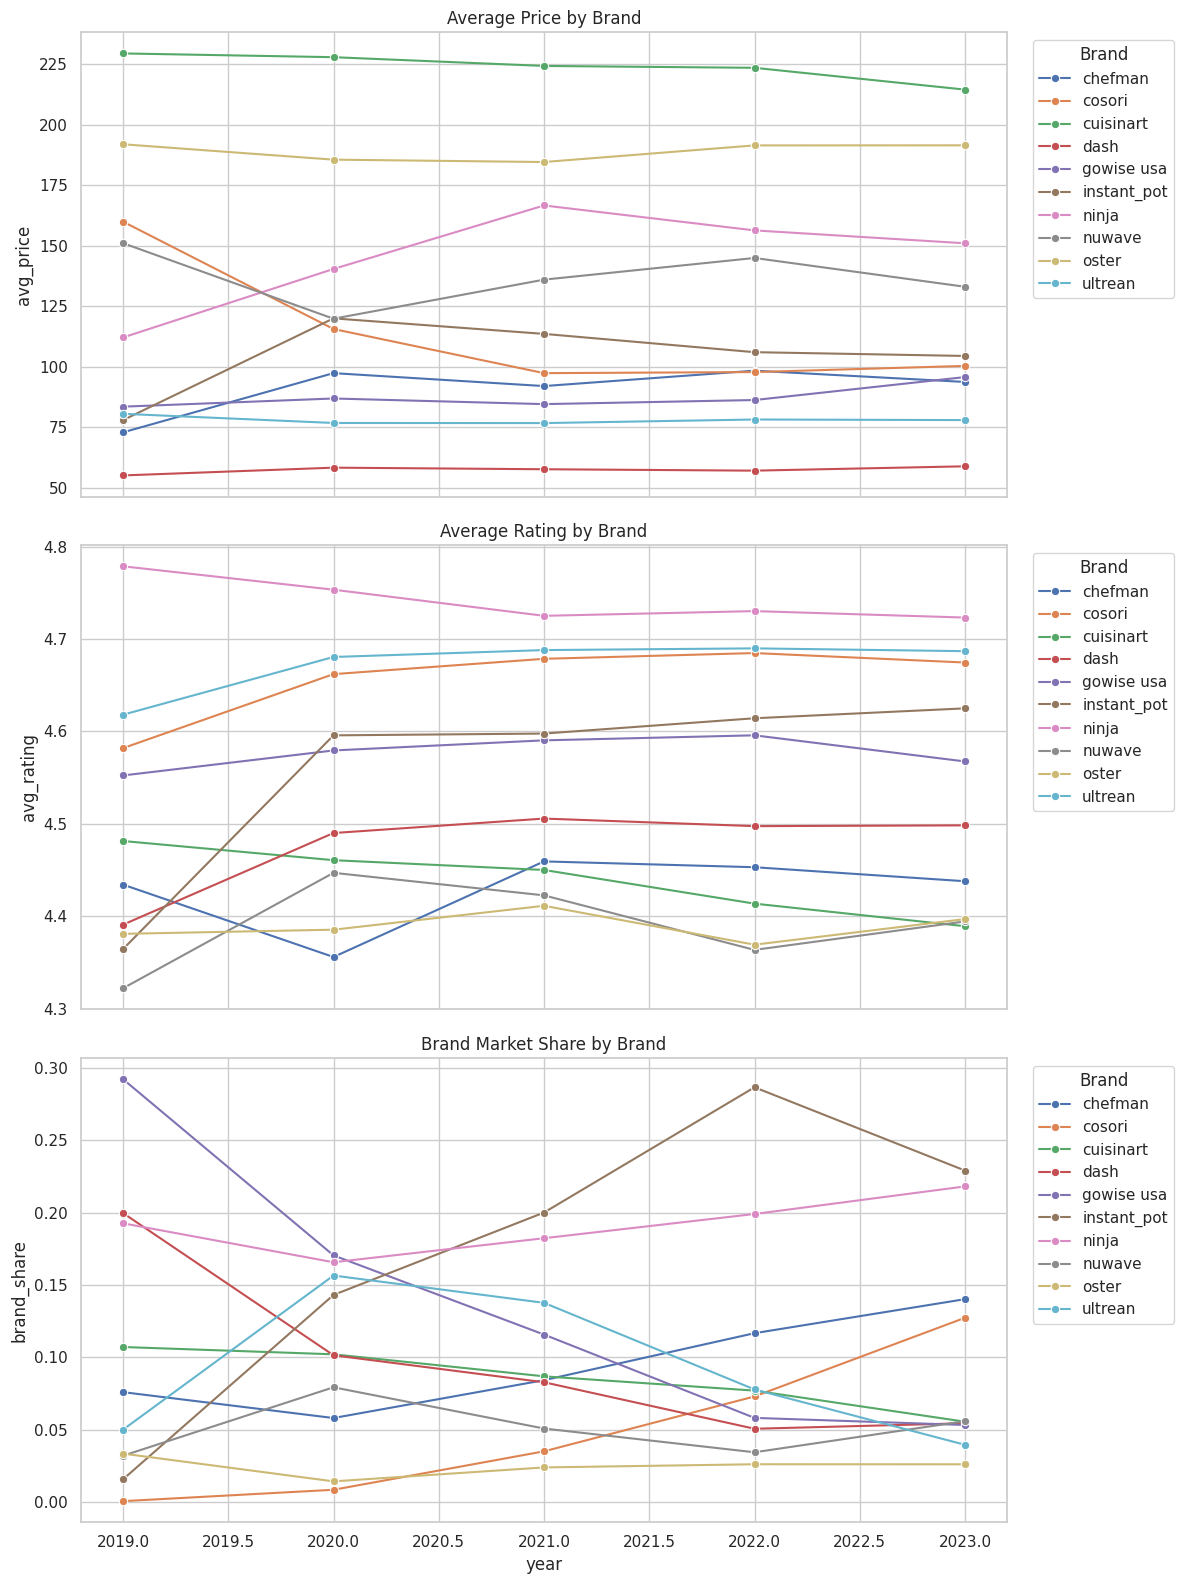


Feature prevalence across the market:


,feature,mean_share
0,compact_share,0.980081
1,oven_style_share,0.562647
2,rotisserie_share,0.070762
3,window_share,0.036741
4,dual_basket_share,0.002260


Brand specialization snapshot:


,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share
brand,,,,,
chefman,0.962,0.013,0.597,0.370,0.363
cosori,0.997,0.000,0.030,0.024,0.000
cuisinart,0.996,0.000,0.913,0.000,0.000
dash,0.999,0.000,0.890,0.000,0.000
gowise usa,1.000,0.000,0.184,0.184,0.001
instant_pot,0.860,0.000,0.675,0.102,0.003
ninja,0.992,0.002,0.100,0.000,0.000
nuwave,0.995,0.007,0.543,0.027,0.000
oster,1.000,0.000,0.865,0.000,0.000


Average price/rating/share by brand:


,avg_price,avg_rating,avg_share
brand,,,
ninja,145.343,4.742,0.192
instant_pot,104.461,4.559,0.175
gowise usa,87.455,4.577,0.138
dash,57.479,4.476,0.098
chefman,90.938,4.428,0.095
ultrean,78.115,4.673,0.092
cuisinart,223.947,4.439,0.086
nuwave,137.024,4.390,0.051
cosori,114.268,4.656,0.049


Top brands by feature:

compact_share:
brand
ultrean       1.0
gowise usa    1.0
oster         1.0

dual_basket_share:
brand
chefman    0.013
nuwave     0.007
ninja      0.002

oven_style_share:
brand
cuisinart    0.913
dash         0.890
oster        0.865

rotisserie_share:
brand
chefman        0.370
gowise usa     0.184
instant_pot    0.102

window_share:
brand
chefman        0.363
instant_pot    0.003
gowise usa     0.001

Short answer:
- Common features: ['compact_share', 'oven_style_share']
- Rare features: ['rotisserie_share', 'window_share', 'dual_basket_share']
- Most expensive brands: ['cuisinart', 'oster', 'ninja']
- Largest-share brands: ['ninja', 'instant_pot', 'gowise usa']
- Most stable shares: ['oster', 'nuwave', 'ninja']
- Least stable shares: ['dash', 'gowise usa', 'instant_pot']
- Specialization: most brands are heavily compact; Cuisinart/Dash/Oster are most oven-style,
  Chefman and GoWise USA show the strongest rotisserie presence, and Chefman leads in window-share

In [3]:
# 1. Data Analysis

brands = sorted(df["brand"].unique())
years = sorted(df["year"].unique())

print("Number of brands:", len(brands))
print("Brands:", brands)
print("Years:", years)
print("Contains 10 brands and years 2019-2023:", len(brands) == 10 and years == [2019, 2020, 2021, 2022, 2023])

fig, axes = plt.subplots(3, 1, figsize=(12, 16), sharex=True)
plot_specs = [
    ("avg_price", "Average Price by Brand"),
    ("avg_rating", "Average Rating by Brand"),
    ("brand_share", "Brand Market Share by Brand"),
]

for ax, (col, title) in zip(axes, plot_specs):
    sns.lineplot(data=df, x="year", y=col, hue="brand", marker="o", ax=ax)
    ax.set_title(title)
    ax.legend(title="Brand", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

feature_means = (
    df[feature_cols]
    .mean()
    .sort_values(ascending=False)
    .rename("mean_share")
    .reset_index()
    .rename(columns={"index": "feature"})
)

brand_features = df.groupby("brand")[feature_cols].mean().round(3)

price_share_summary = (
    df.groupby("brand")
    .agg(
        avg_price=("avg_price", "mean"),
        avg_rating=("avg_rating", "mean"),
        avg_share=("brand_share", "mean"),
    )
    .sort_values("avg_share", ascending=False)
    .round(3)
)

print("\nFeature prevalence across the market:")
display(feature_means)

print("Brand specialization snapshot:")
display(brand_features)

print("Average price/rating/share by brand:")
display(price_share_summary)

feature_leaders = {
    feature: brand_features[feature].sort_values(ascending=False).head(3)
    for feature in feature_cols
}

print("Top brands by feature:")
for feature, leaders in feature_leaders.items():
    print(f"\n{feature}:")
    print(leaders.to_string())

expensive = price_share_summary.sort_values("avg_price", ascending=False).head(3).index.tolist()
high_share = price_share_summary.sort_values("avg_share", ascending=False).head(3).index.tolist()
share_sd = df.groupby("brand")["brand_share"].std().sort_values()
stable = share_sd.head(3).index.tolist()
least_stable = share_sd.tail(3).index.tolist()
common_features = feature_means[feature_means["mean_share"] > 0.5]["feature"].tolist()
rare_features = feature_means[feature_means["mean_share"] < 0.1]["feature"].tolist()

print("\nShort answer:")
print(f"- Common features: {common_features}")
print(f"- Rare features: {rare_features}")
print(f"- Most expensive brands: {expensive}")
print(f"- Largest-share brands: {high_share}")
print(f"- Most stable shares: {stable}")
print(f"- Least stable shares: {least_stable}")
print("- Specialization: most brands are heavily compact; Cuisinart/Dash/Oster are most oven-style,")
print("  Chefman and GoWise USA show the strongest rotisserie presence, and Chefman leads in window-share products.")



The air fryer market appears moderately concentrated and fairly stable over 2019-2023, with a few brands consistently holding the largest shares. Ninja, Instant Pot, and GoWise USA have the highest average market shares, suggesting they are the main volume leaders in this sample. On the pricing side, Cuisinart and Oster are the most expensive brands on average, with Ninja also positioned toward the premium end, while brands like Dash compete at much lower prices. Ninja, Ultrean, and Cosori lead in brand ratings. Overall, the market does not show dramatic year-to-year upheaval, although some brands experience more share movement than others. The main competitive ranking is fairly persistent over time.

## 2. Demand Estimation

We will estimate a logit-style demand model using linear regression. The model is:

$$
\log(s_{bt}) = \alpha_0 + \alpha_t + \gamma_b + \beta_{price}p_{bt} + \beta_{rating}r_{bt} + \sum_{\ell=1}^L \beta_\ell x_{bt\ell} + \epsilon_{bt}.
$$

Here:

- $b$ indexes brands
- $t$ indexes years
- $s_{bt}$ is `brand_share`
- $p_{bt}$ is `avg_price`
- $r_{bt}$ is `avg_rating`
- $x_{bt\ell}$ are the product characteristics
- $\alpha_t$ are year dummy coefficients
- $\gamma_b$ are brand dummy coefficients
- $\beta_{price}$ is **one constant price coefficient**, shared by all brands and all years

That last point matters: do **not** estimate a different price coefficient for every brand-year. We do not have enough information for that, and it would make the cost calculation impossible to interpret.

Use `pd.get_dummies(..., drop_first=True)` for brand and year dummies. The dropped brand and dropped year become the reference categories, so all dummy coefficients are interpreted relative to those omitted categories.

Questions:

1. What is the estimated price coefficient, $\hat{\beta}_{price}$?
2. Is it negative? Why is that important?
3. Which product features are associated with higher demand?
4. Which brand dummy coefficients are largest? Remember that these are interpreted relative to the dropped brand.
5. Which year dummy coefficients are largest? Remember that these are interpreted relative to the dropped year.
6. What is the model's $R^2$?

This part of the work is the **data scientist** role: turning the cleaned data into a model that can be used for prediction and interpretation.

In [4]:
# 2. Demand Estimation

y = df["log_brand_share"]

X = df[["avg_price", "avg_rating"] + feature_cols].copy()
X = pd.concat(
    [
        X,
        pd.get_dummies(df["brand"], prefix="brand", drop_first=True),
        pd.get_dummies(df["year"], prefix="year", drop_first=True),
    ],
    axis=1,
)

X = X.astype(float)
X.insert(0, "const", 1.0)

beta, *_ = np.linalg.lstsq(X.values, y.values, rcond=None)
coef = pd.Series(beta, index=X.columns)

y_hat = X.values @ beta
r2 = 1 - np.sum((y.values - y_hat) ** 2) / np.sum((y.values - y.mean()) ** 2)

feature_effects = coef[feature_cols].sort_values(ascending=False)
brand_effects = coef[[c for c in coef.index if c.startswith("brand_")]].sort_values(ascending=False)
year_effects = coef[[c for c in coef.index if c.startswith("year_")]].sort_values(ascending=False)

print("Estimated price coefficient:", coef["avg_price"])
print("Is it negative?", coef["avg_price"] < 0)
print("Estimated rating coefficient:", coef["avg_rating"])
print("R-squared:", r2)

print("\nFeature coefficients:")
display(feature_effects.to_frame("coefficient"))

print("Brand dummy coefficients (relative to dropped brand):")
display(brand_effects.to_frame("coefficient"))

print("Year dummy coefficients (relative to dropped year):")
display(year_effects.to_frame("coefficient"))

print("\nShort answers:")
print(f"1. Price coefficient = {coef['avg_price']:.6f}")
print("2. Yes, it is negative, which is important because demand should fall as price rises.")
print(f"3. Highest-demand features: {feature_effects.head(3).to_dict()}")
print(f"   Lowest-demand features: {feature_effects.tail(2).to_dict()}")
print(f"4. Largest brand dummy coefficients: {brand_effects.head(5).to_dict()}")
print(f"5. Largest year dummy coefficients: {year_effects.to_dict()}")
print(f"6. R^2 = {r2:.4f}")


Estimated price coefficient: -0.0376676529842938
Is it negative? True
Estimated rating coefficient: 0.2875168474327795
R-squared: 0.7634539500914359

Feature coefficients:


,coefficient
window_share,12.880298
compact_share,9.815304
oven_style_share,1.941774
rotisserie_share,-5.674054
dual_basket_share,-9.509686


Brand dummy coefficients (relative to dropped brand):


,coefficient
brand_cuisinart,6.422436
brand_ninja,5.838705
brand_instant_pot,4.626260
brand_gowise usa,3.938996
brand_oster,3.928074
brand_nuwave,3.544883
brand_cosori,2.551946
brand_ultrean,0.942399
brand_dash,0.176655


Year dummy coefficients (relative to dropped year):


,coefficient
year_2020,0.119071
year_2021,0.041900
year_2023,-0.003307
year_2022,-0.098860



Short answers:
1. Price coefficient = -0.037668
2. Yes, it is negative, which is important because demand should fall as price rises.
3. Highest-demand features: {'window_share': 12.88029789072312, 'compact_share': 9.815303774308049, 'oven_style_share': 1.9417744851002443}
   Lowest-demand features: {'rotisserie_share': -5.67405425270827, 'dual_basket_share': -9.509685698085379}
4. Largest brand dummy coefficients: {'brand_cuisinart': 6.422435556102869, 'brand_ninja': 5.838705148242797, 'brand_instant_pot': 4.626259635483636, 'brand_gowise usa': 3.938996459257718, 'brand_oster': 3.928073752404413}
5. Largest year dummy coefficients: {'year_2020': 0.11907093654217539, 'year_2021': 0.04190030825488007, 'year_2023': -0.0033070241419464, 'year_2022': -0.09886024816305383}
6. R^2 = 0.7635


## 3. Strategy: Costs, Markups, and Profit

Now use the demand estimate to infer market fundamentals.

The price coefficient is constant across brands and years, $\hat{\beta}_{price}$.

For each brand-year, compute the slope of demand with respect to price as:

$$
\hat{s}'_{bt}(p_{bt}) = \hat{\beta}_{price} s_{bt}(1 - s_{bt}).
$$

Then estimate unit cost, or marginal cost, using the firm's first-order pricing condition:

$$
\hat{c}_{bt} = p_{bt} + \frac{s_{bt}}{\hat{s}'_{bt}(p_{bt})}.
$$

Because $\hat{\beta}_{price}$ should be negative, $\hat{s}'_{bt}(p_{bt})$ should also be negative. If your price coefficient is positive, stop and debug your model before interpreting costs.

Compute:

- `demand_slope`: $\hat{s}'_{bt}(p_{bt})$
- `unit_cost`: $\hat{c}_{bt}$
- `markup`: $m_{bt} = p_{bt} - \hat{c}_{bt}$
- `average_profit`: $s_{bt} \times m_{bt}$

Here `average_profit` is a share-weighted profit index, not total dollars of profit. It is useful for comparing brand-years inside this cleaned market.

Questions:

1. What are the average unit costs and markups for each brand over the years?
2. Are any inferred unit costs negative? If so, what might that mean?
3. Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Make scatter plots of price vs. unit cost and average rating vs. unit cost.Do more expensive products have higher consumer satisfaction?
4. Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand.
5. Which brands have the highest share-weighted average profit?

This part of the work is the **pricing analyst** or **applied economist** role: using a demand model to reason about price, cost, and profitability. This kind of analysis could be used to think about investing in this market, or how to adjust a product line to be more competitive.

,avg_price,avg_rating,avg_share,avg_unit_cost,avg_markup,avg_profit
brand,,,,,,
ninja,145.343,4.742,0.192,112.488,32.854,6.306
instant_pot,104.461,4.559,0.175,71.903,32.558,6.010
gowise usa,87.455,4.577,0.138,56.301,31.154,4.606
dash,57.479,4.476,0.098,27.937,29.542,2.994
chefman,90.938,4.428,0.095,61.569,29.369,2.821
ultrean,78.115,4.673,0.092,48.786,29.329,2.781
cuisinart,223.947,4.439,0.086,194.896,29.051,2.503
cosori,114.268,4.656,0.049,86.283,27.985,1.437
nuwave,137.024,4.390,0.051,109.054,27.971,1.423


Negative unit-cost rows: 0


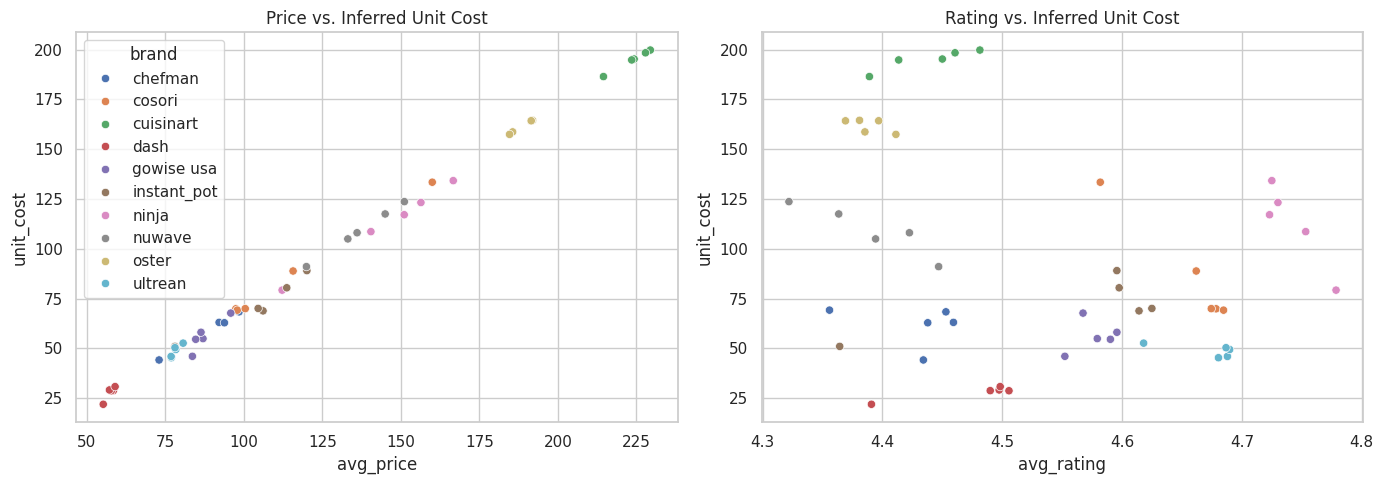

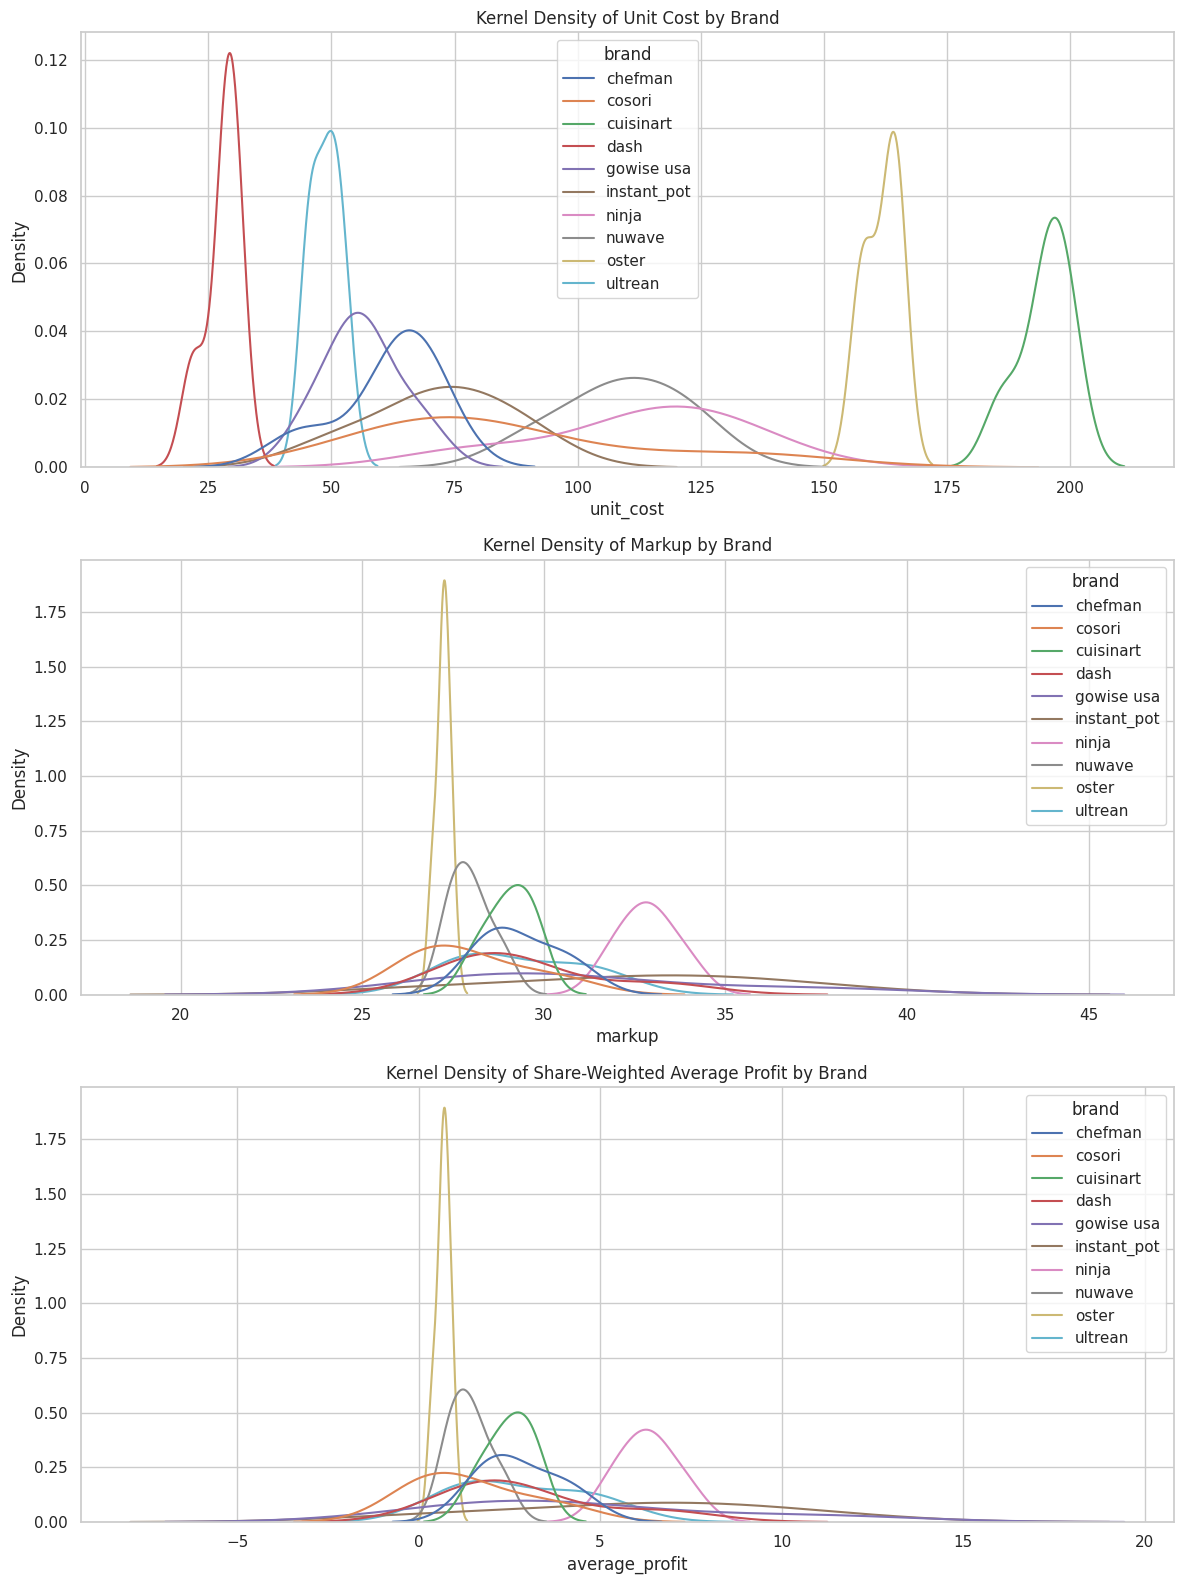

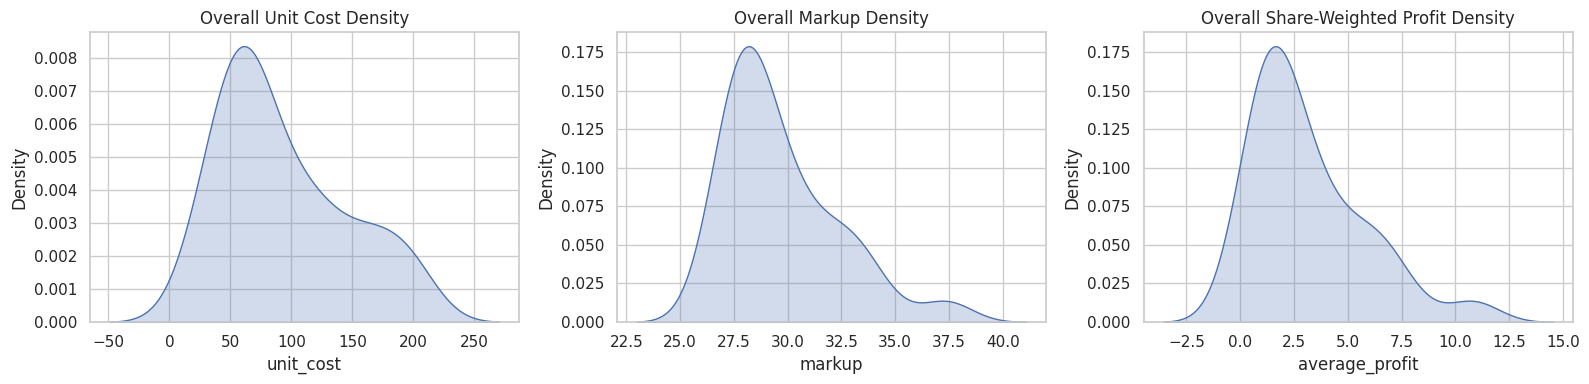


Top brands by average unit cost:


,avg_price,avg_rating,avg_share,avg_unit_cost,avg_markup,avg_profit
brand,,,,,,
cuisinart,223.947,4.439,0.086,194.896,29.051,2.503
oster,189.031,4.389,0.025,161.805,27.226,0.678
ninja,145.343,4.742,0.192,112.488,32.854,6.306
nuwave,137.024,4.390,0.051,109.054,27.971,1.423
cosori,114.268,4.656,0.049,86.283,27.985,1.437


Top brands by share-weighted average profit:


,avg_price,avg_rating,avg_share,avg_unit_cost,avg_markup,avg_profit
brand,,,,,,
ninja,145.343,4.742,0.192,112.488,32.854,6.306
instant_pot,104.461,4.559,0.175,71.903,32.558,6.010
gowise usa,87.455,4.577,0.138,56.301,31.154,4.606
dash,57.479,4.476,0.098,27.937,29.542,2.994
chefman,90.938,4.428,0.095,61.569,29.369,2.821



Short answers:
1. Average unit costs and markups are shown in the brand summary table.
2. Any negative unit costs? False
3. Correlation between price and unit cost: 0.9988
   Correlation between rating and unit cost: -0.3139
   More expensive products do have higher inferred unit costs here, but higher unit cost does not imply higher ratings.
4. KDE plots for unit costs, markups, and average profit are shown above.
5. Highest share-weighted average profit brands: ['ninja', 'instant_pot', 'gowise usa', 'dash', 'chefman']


In [5]:
# 3. Strategy: Costs, Markups, and Profit

results = df.copy()
results["demand_slope"] = coef["avg_price"] * results["brand_share"] * (1 - results["brand_share"])
results["unit_cost"] = results["avg_price"] + results["brand_share"] / results["demand_slope"]
results["markup"] = results["avg_price"] - results["unit_cost"]
results["average_profit"] = results["brand_share"] * results["markup"]

brand_summary = (
    results.groupby("brand")
    .agg(
        avg_price=("avg_price", "mean"),
        avg_rating=("avg_rating", "mean"),
        avg_share=("brand_share", "mean"),
        avg_unit_cost=("unit_cost", "mean"),
        avg_markup=("markup", "mean"),
        avg_profit=("average_profit", "mean"),
    )
    .sort_values("avg_profit", ascending=False)
    .round(3)
)

display(brand_summary)

negative_costs = results.loc[results["unit_cost"] < 0, ["brand", "year", "unit_cost"]]
print("Negative unit-cost rows:", len(negative_costs))
if len(negative_costs) > 0:
    display(negative_costs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=results, x="avg_price", y="unit_cost", hue="brand", ax=axes[0])
axes[0].set_title("Price vs. Inferred Unit Cost")

sns.scatterplot(data=results, x="avg_rating", y="unit_cost", hue="brand", ax=axes[1], legend=False)
axes[1].set_title("Rating vs. Inferred Unit Cost")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(12, 16))
sns.kdeplot(data=results, x="unit_cost", hue="brand", fill=False, common_norm=False, ax=axes[0])
axes[0].set_title("Kernel Density of Unit Cost by Brand")

sns.kdeplot(data=results, x="markup", hue="brand", fill=False, common_norm=False, ax=axes[1])
axes[1].set_title("Kernel Density of Markup by Brand")

sns.kdeplot(data=results, x="average_profit", hue="brand", fill=False, common_norm=False, ax=axes[2])
axes[2].set_title("Kernel Density of Share-Weighted Average Profit by Brand")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.kdeplot(data=results, x="unit_cost", fill=True, ax=axes[0])
axes[0].set_title("Overall Unit Cost Density")

sns.kdeplot(data=results, x="markup", fill=True, ax=axes[1])
axes[1].set_title("Overall Markup Density")

sns.kdeplot(data=results, x="average_profit", fill=True, ax=axes[2])
axes[2].set_title("Overall Share-Weighted Profit Density")

plt.tight_layout()
plt.show()

top_unit_cost = brand_summary.sort_values("avg_unit_cost", ascending=False).head(5)
top_profit = brand_summary.sort_values("avg_profit", ascending=False).head(5)

price_cost_corr = results["avg_price"].corr(results["unit_cost"])
rating_cost_corr = results["avg_rating"].corr(results["unit_cost"])

print("\nTop brands by average unit cost:")
display(top_unit_cost)

print("Top brands by share-weighted average profit:")
display(top_profit)

print("\nShort answers:")
print("1. Average unit costs and markups are shown in the brand summary table.")
print(f"2. Any negative unit costs? {len(negative_costs) > 0}")
print(f"3. Correlation between price and unit cost: {price_cost_corr:.4f}")
print(f"   Correlation between rating and unit cost: {rating_cost_corr:.4f}")
print("   More expensive products do have higher inferred unit costs here, but higher unit cost does not imply higher ratings.")
print("4. KDE plots for unit costs, markups, and average profit are shown above.")
print(f"5. Highest share-weighted average profit brands: {top_profit.index.tolist()}")


## 4. Results

Submit a GitHub repo containing:

1. A notebook corresponding to the data analyst work, including the code and graphs, explicitly answering the questions above in text markdown chunks
2. A notebook corresponding to the data scientist work, including the code and graphs, explicitly answering the questions above in text markdown chunks
3. A notebook corresponding to the pricing analyst work, including the code and graphs, explicitly answering the questions above in text markdown chunks
4. A short presentation of your findings, about 5-8 slides.

Your presentation should be written as if you were giving market intelligence to a business audience. It should include:

- A short description of the air-fryer market
- A few plots showing prices, ratings, and market shares over time
- A short explanation of the demand model (multinomial logistic regression, estimated by linear regression on log market share)
- The estimated price coefficient and why its sign matters
- A discussion of the most important product features
- Estimated unit costs, markups, and share-weighted profits
- A conclusion about the brands' relative positions in the market

Do not fill slides with raw code. Use your code to produce clear tables and figures, then explain the market story in words.